# Support Device Inpainting with Cheff

This notebook shows how to remove support devices by converting a 256x256 segmentation mask into the 64x64 latent-space mask expected by Cheff.

In [1]:
import os
os.chdir('..')

import torch
import torch.nn.functional as F
from PIL import Image
from torchvision.utils import make_grid
from torchvision.transforms.functional import to_pil_image, to_tensor, resize
from torchvision.transforms import InterpolationMode

## Load Cheff LDM

For inpainting, the same unconditional LDM can be used.

In [2]:
from cheff import CheffLDM

device = 'cuda'
sdm_path = 'trained_models/cheff_diff_uncond.pt'
ae_path = 'trained_models/cheff_autoencoder.pt'

cheff_ldm = CheffLDM(model_path=sdm_path, ae_path=ae_path, device=device)

## Load the Input Image and a 256x256 Segmentation Mask

The image is expected to be 256x256. The segmentation mask should also be 256x256, where white indicates support-device pixels.

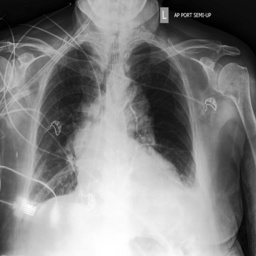

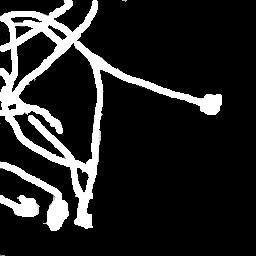

In [4]:
img_path = 'assets/device.jpg'
seg_mask_path = 'assets/device_mask.jpg'

img = Image.open(img_path).convert('L')
seg_mask = Image.open(seg_mask_path).convert('L')

display(img)
display(seg_mask)

img = to_tensor(img).to(device)
img = img * 2 - 1

if img.shape[0] == 1:
    img = img.expand(3, -1, -1)

## Convert the 256x256 Segmentation Mask into a 64x64 Inpainting Mask

Cheff inpainting expects a binary mask in latent space. In the segmentation mask, white means device. In the inpainting mask, zero means regenerate this region.

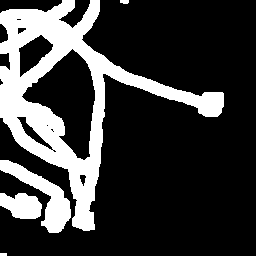

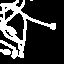

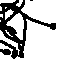

In [8]:
seg_mask_256 = to_tensor(seg_mask)
seg_mask_256 = (seg_mask_256 > 0.5).float()

# Optional: dilate the segmentation mask so thin tubes and lines are fully covered.
dilation = 5
pad = dilation // 2
seg_mask_256 = F.max_pool2d(seg_mask_256.unsqueeze(0), kernel_size=dilation, stride=1, padding=pad).squeeze(0)
seg_mask_256 = (seg_mask_256 > 0.0).float()

device_mask_64 = resize(seg_mask_256, [64, 64], interpolation=InterpolationMode.NEAREST)
device_mask_64 = (device_mask_64 > 0.5).float()

# Cheff uses 1 to keep the original content and 0 to regenerate it.
inpaint_mask_64 = 1.0 - device_mask_64
inpaint_mask_64 = inpaint_mask_64.to(device)

display(to_pil_image(seg_mask_256.cpu()))
display(to_pil_image(device_mask_64.cpu()))
display(to_pil_image(inpaint_mask_64.cpu()))

## Run Inpainting

The image stays at 256x256, while the mask is expanded from 64x64 latent space to the batch shape expected by `sample_inpaint`.

Data shape for DDIM sampling is (4, 3, 64, 64), eta 1.0
Running DDIM Sampling with 100 timesteps


DDIM Sampler: 100%|█████████████████████████████████████████████████████████████████| 100/100 [00:07<00:00, 13.73it/s]


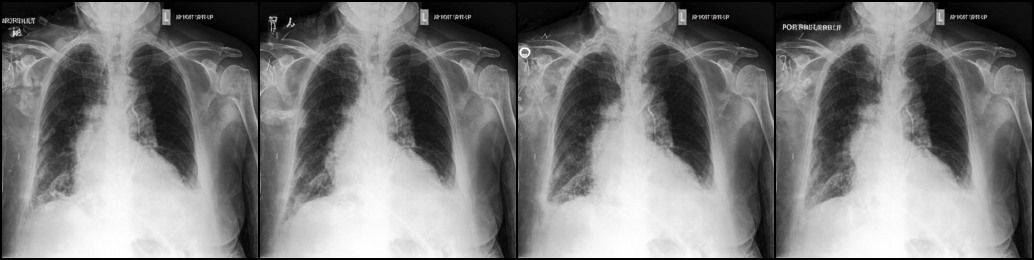

In [9]:
imgs = img.unsqueeze(0).expand(4, -1, -1, -1)
masks = inpaint_mask_64.unsqueeze(0).expand(4, -1, -1, -1)

imgs_edited = cheff_ldm.sample_inpaint(
    target_img=imgs,
    mask=masks,
    sampling_steps=100,
)

imgs_edited.clamp_(-1, 1)
imgs_edited = (imgs_edited + 1) / 2

img_grid = make_grid(imgs_edited.cpu())
display(to_pil_image(img_grid))

## Compare the Original Image and the Edited Outputs

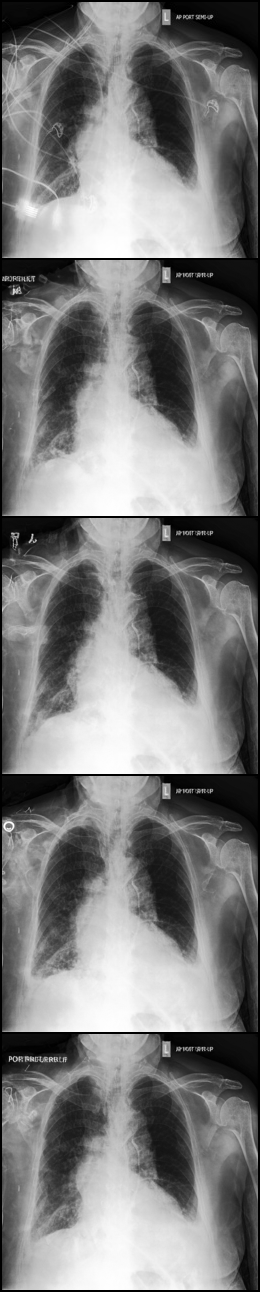

In [10]:
original = ((img.detach().cpu() + 1) / 2).unsqueeze(0)
original = original[:, :1]
edited = imgs_edited[:, :1].cpu()
comparison = torch.cat([original, edited], dim=0)
comparison_grid = make_grid(comparison, nrow=1)
display(to_pil_image(comparison_grid))